# Linear Regression Multiple Variables


In [23]:
# Imports and data load
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", 60)
np.random.seed(0)

csv_file = "telco.csv"
df = pd.read_csv(csv_file)

df.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,target,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,29.85,29.85,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,0,0,0,0,56.95,1889.5,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,0,0,0,1,53.85,108.15,1,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,1,0,1,1,0,0,0,42.30,1840.75,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,0,0,0,0,0,0,0,1,70.70,151.65,1,1,0,0,0,0,1,0


## 1. Inspect the data

In [24]:
display(df.head(3))
print("shape:", df.shape)
display(df.describe())
df.info()
print("Missing values:")
display(df.isnull().sum())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,target,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,0,0,0,1,29.85,29.85,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,1,0,1,0,0,0,0,56.95,1889.5,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,0,1,1,0,0,0,0,1,53.85,108.15,1,0,0,0,0,0,0,1


shape: (7043, 24)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,target,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.504756,0.162147,0.483033,0.299588,32.371149,0.903166,0.421837,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903,0.592219,64.761692,0.265370,0.439585,0.216669,0.209144,0.240664,0.216101,0.335794,0.228880
std,0.500013,0.368612,0.499748,0.458110,24.559481,0.295752,0.493888,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,0.491457,30.090047,0.441561,0.496372,0.412004,0.406726,0.427517,0.411613,0.472301,0.420141
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.850000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   MultipleLines                          7043 non-null   int64  
 7   OnlineSecurity                         7043 non-null   int64  
 8   OnlineBackup                           7043 non-null   int64  
 9   DeviceProtection                       7043 non-null   int64  
 10  TechSupport                            7043 non-null   int64  
 11  StreamingTV    

gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
MultipleLines                            0
OnlineSecurity                           0
OnlineBackup                             0
DeviceProtection                         0
TechSupport                              0
StreamingTV                              0
StreamingMovies                          0
PaperlessBilling                         0
target                                   0
TotalCharges                             0
Churn                                    0
InternetService_Fiber optic              0
InternetService_No                       0
Contract_One year                        0
Contract_Two year                        0
PaymentMethod_Credit card (automatic)    0
PaymentMethod_Electronic check           0
PaymentMeth

## 2. Clean and prepare the service columns

In [25]:
# Clean and prepare data


feature_cols = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'InternetService_Fiber optic', 'InternetService_No'
]

X = df[feature_cols]
y = df["target"]

print("Dataset shape:", df.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

Dataset shape: (7043, 24)
X shape: (7043, 10)
y shape: (7043,)


,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,InternetService_Fiber optic,InternetService_No
0,0,0,0,1,0,0,0,0,0,0
1,1,0,1,0,1,0,0,0,0,0
2,1,0,1,1,0,0,0,0,0,0
3,0,0,1,0,1,1,0,0,0,0
4,1,0,0,0,0,0,0,0,1,0


## 3. Define the required predictors and target

In [26]:
feature_cols = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'InternetService_Fiber optic', 'InternetService_No'
]

X = df[feature_cols]
y = df['target']

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head(3)

X shape: (7043, 10)
y shape: (7043,)


,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,InternetService_Fiber optic,InternetService_No
0,0,0,0,1,0,0,0,0,0,0
1,1,0,1,0,1,0,0,0,0,0
2,1,0,1,1,0,0,0,0,0,0


## 4. Verify the model data

In [27]:
print("Target column:", y.name)
print("Number of predictors:", X.shape[1])
print("Any missing values in X?", X.isnull().any().any())
print("Any missing values in y?", y.isnull().any())

print("Unique values in each service predictor:")
for col in feature_cols:
    print(col, sorted(X[col].unique()))

Target column: target
Number of predictors: 10
Any missing values in X? False
Any missing values in y? False
Unique values in each service predictor:
PhoneService [np.int64(0), np.int64(1)]
MultipleLines [np.int64(0), np.int64(1)]
OnlineSecurity [np.int64(0), np.int64(1)]
OnlineBackup [np.int64(0), np.int64(1)]
DeviceProtection [np.int64(0), np.int64(1)]
TechSupport [np.int64(0), np.int64(1)]
StreamingTV [np.int64(0), np.int64(1)]
StreamingMovies [np.int64(0), np.int64(1)]
InternetService_Fiber optic [np.int64(0), np.int64(1)]
InternetService_No [np.int64(0), np.int64(1)]


## 5. Train/test split and fit the multivariable model

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("First 10 predictions:", y_pred[:10].round(2))

Training rows: 5634
Testing rows: 1409
First 10 predictions: [ 24.97  24.97  19.96  74.97  50.03  89.9   75.08  70.08 104.97  19.96]


## 6. Report the intercept and coefficients

In [29]:
print("Base plan / intercept: $%.2f per month" % model.intercept_)

price_list = (
    pd.DataFrame({"service": feature_cols, "coefficient": model.coef_})
    .sort_values("coefficient", ascending=False)
    .reset_index(drop=True)
)

price_list

Base plan / intercept: $24.97 per month


,service,coefficient
0,InternetService_Fiber optic,24.951892
1,PhoneService,20.036039
2,StreamingTV,9.980786
3,StreamingMovies,9.946628
4,OnlineSecurity,5.045880
5,TechSupport,5.028676
6,MultipleLines,5.012293
7,DeviceProtection,5.011923
8,OnlineBackup,4.979713
9,InternetService_No,-25.047916


## 7. Evaluate the multivariable model

In [30]:
multi_r2 = r2_score(y_test, y_pred)
multi_mae = mean_absolute_error(y_test, y_pred)
multi_rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("Multivariable Model Results")
print("R2:", multi_r2)
print("MAE:", multi_mae)
print("RMSE:", multi_rmse)

Multivariable Model Results
R2: 0.998781248648184
MAE: 0.7886422818560813
RMSE: 1.0504411196100751


## 8. Baseline model: count of add-ons only

In [31]:
df["num_addons"] = df[feature_cols].sum(axis=1)

X_base = df[["num_addons"]]
y_base = df["target"]

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_base, y_base, test_size=0.2, random_state=42
)

baseline_model = LinearRegression()
baseline_model.fit(Xb_train, yb_train)

yb_pred = baseline_model.predict(Xb_test)

baseline_r2 = r2_score(yb_test, yb_pred)
baseline_mae = mean_absolute_error(yb_test, yb_pred)
baseline_rmse = mean_squared_error(yb_test, yb_pred) ** 0.5

print("Baseline Model Results")
print("R2:", baseline_r2)
print("MAE:", baseline_mae)
print("RMSE:", baseline_rmse)

Baseline Model Results
R2: 0.7009290873134922
MAE: 14.236908934155862
RMSE: 16.45512731172397


## 9. Compare both models

In [32]:
comparison = pd.DataFrame({
    "Model": ["Single-variable baseline: num_addons", "Multivariable: 10 service indicators"],
    "R2": [baseline_r2, multi_r2],
    "MAE": [baseline_mae, multi_mae],
    "RMSE": [baseline_rmse, multi_rmse]
})

comparison

,Model,R2,MAE,RMSE
0,Single-variable baseline: num_addons,0.700929,14.236909,16.455127
1,Multivariable: 10 service indicators,0.998781,0.788642,1.050441


## 10. Make a prediction for a new customer bundle

In [33]:
# Example: phone service, multiple lines, and tech support
new_customer = pd.DataFrame([{
    "PhoneService": 1,
    "MultipleLines": 1,
    "OnlineSecurity": 0,
    "OnlineBackup": 0,
    "DeviceProtection": 0,
    "TechSupport": 1,
    "StreamingTV": 0,
    "StreamingMovies": 0,
    "InternetService_Fiber optic": 0,
    "InternetService_No": 0
}])

predicted_charge = model.predict(new_customer)[0]
print("Predicted monthly charge: $%.2f" % predicted_charge)

Predicted monthly charge: $55.05


## 11. Business questions

In [34]:
positive_services = price_list[price_list["coefficient"] > 0].copy()
most_expensive = positive_services.sort_values("coefficient", ascending=False).iloc[0]
cheapest_addon = positive_services.sort_values("coefficient", ascending=True).iloc[0]
lowest_coefficient = price_list.sort_values("coefficient", ascending=True).iloc[0]

fiber_streaming_rise = (
    price_list.loc[price_list["service"] == "InternetService_Fiber optic", "coefficient"].iloc[0]
    + price_list.loc[price_list["service"] == "StreamingTV", "coefficient"].iloc[0]
    + price_list.loc[price_list["service"] == "StreamingMovies", "coefficient"].iloc[0]
)

print("1. Estimated base plan cost: $%.2f" % model.intercept_)
print("2. Each coefficient estimates the monthly dollar contribution of that service.")
print("3. Most expensive positive service:", most_expensive["service"], "= $%.2f" % most_expensive["coefficient"])
print("4. Cheapest positive add-on:", cheapest_addon["service"], "= $%.2f" % cheapest_addon["coefficient"])
print("   Lowest coefficient overall:", lowest_coefficient["service"], "= $%.2f" % lowest_coefficient["coefficient"])
print("   Note: InternetService_No is negative because customers with no internet service pay less.")
print("5. Fiber internet + StreamingTV + StreamingMovies bill rise: $%.2f" % fiber_streaming_rise)
print("6. Example bundle predicted monthly charge: $%.2f" % predicted_charge)
print("7. Multivariable R2 vs baseline R2:", round(multi_r2, 4), "vs", round(baseline_r2, 4))
print("8. Multivariable MAE vs baseline MAE:", round(multi_mae, 4), "vs", round(baseline_mae, 4))

1. Estimated base plan cost: $24.97
2. Each coefficient estimates the monthly dollar contribution of that service.
3. Most expensive positive service: InternetService_Fiber optic = $24.95
4. Cheapest positive add-on: OnlineBackup = $4.98
   Lowest coefficient overall: InternetService_No = $-25.05
   Note: InternetService_No is negative because customers with no internet service pay less.
5. Fiber internet + StreamingTV + StreamingMovies bill rise: $44.88
6. Example bundle predicted monthly charge: $55.05
7. Multivariable R2 vs baseline R2: 0.9988 vs 0.7009
8. Multivariable MAE vs baseline MAE: 0.7886 vs 14.2369


## 12. Actual vs predicted sample

In [35]:
results = X_test.copy()
results["actual"] = y_test.values
results["predicted"] = y_pred.round(2)
results["error"] = (results["actual"] - results["predicted"]).round(2)
results.head(10)

,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,InternetService_Fiber optic,InternetService_No,actual,predicted,error
185,0,0,0,0,0,0,0,0,0,0,24.80,24.97,-0.17
2715,1,1,0,0,0,0,0,0,0,1,25.25,24.97,0.28
3825,1,0,0,0,0,0,0,0,0,1,19.35,19.96,-0.61
1807,1,0,0,0,1,0,0,0,1,0,76.35,74.97,1.38
132,1,0,0,0,0,1,0,0,0,0,50.55,50.03,0.52
1263,1,1,0,1,0,0,0,1,1,0,89.60,89.90,-0.30
3732,1,1,1,0,1,1,1,0,0,0,77.15,75.08,2.07
1672,1,1,1,1,1,1,0,0,0,0,72.10,70.08,2.02
811,1,1,1,0,0,1,1,1,1,0,104.00,104.97,-0.97
2526,1,0,0,0,0,0,0,0,0,1,19.40,19.96,-0.56


## 13. Charts

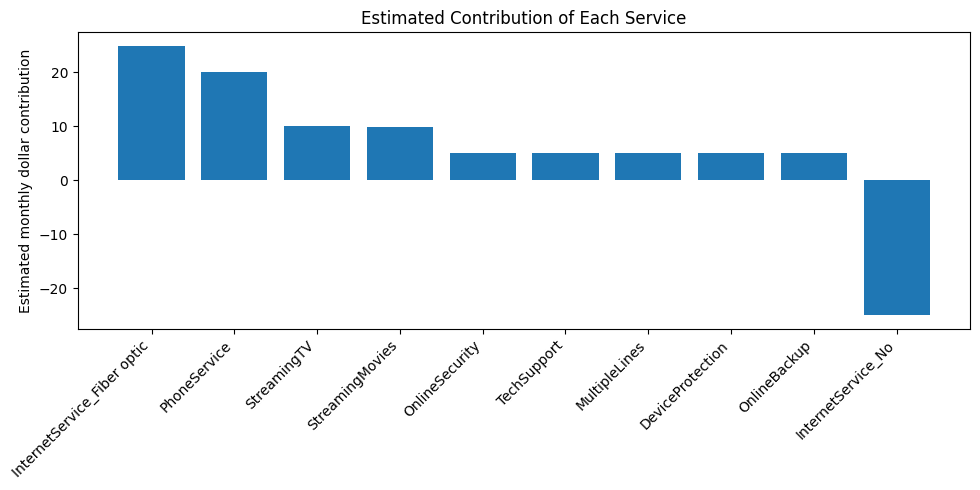

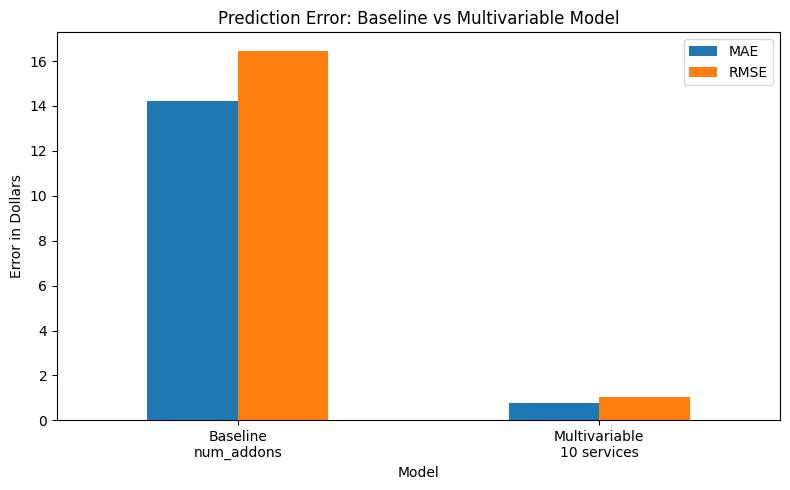

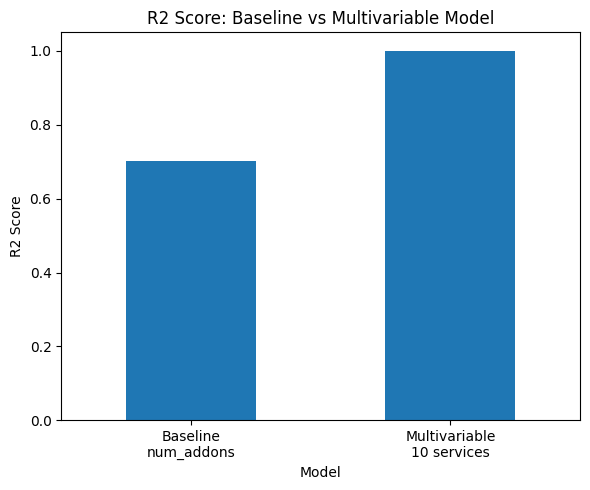

In [36]:
# Chart 1: Coefficients by service
plt.figure(figsize=(10, 5))
plt.bar(price_list["service"], price_list["coefficient"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Estimated monthly dollar contribution")
plt.title("Estimated Contribution of Each Service")
plt.tight_layout()
plt.show()


# Chart 2: MAE and RMSE comparison
error_comparison = comparison[["Model", "MAE", "RMSE"]].copy()

error_comparison["Model"] = [
    "Baseline\nnum_addons",
    "Multivariable\n10 services"
]

error_comparison.plot(
    x="Model",
    y=["MAE", "RMSE"],
    kind="bar",
    figsize=(8, 5)
)

plt.title("Prediction Error: Baseline vs Multivariable Model")
plt.ylabel("Error in Dollars")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# Chart 3: R2 comparison
r2_comparison = comparison[["Model", "R2"]].copy()

r2_comparison["Model"] = [
    "Baseline\nnum_addons",
    "Multivariable\n10 services"
]

r2_comparison.plot(
    x="Model",
    y="R2",
    kind="bar",
    figsize=(6, 5),
    legend=False
)

plt.title("R2 Score: Baseline vs Multivariable Model")
plt.ylabel("R2 Score")
plt.xlabel("Model")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 14. Final verification

In [37]:
required_predictors = [
    'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'InternetService_Fiber optic', 'InternetService_No'
]

print("===== Final Assignment Verification =====")
print("Target variable:", y.name)
print("Number of predictors:", X.shape[1])
print("Predictors match required list:", list(X.columns) == required_predictors)
print("No missing values:", not X.isnull().any().any() and not y.isnull().any())
print("Multivariable R2:", multi_r2)
print("Baseline R2:", baseline_r2)
print("Multivariable beats baseline by R2:", multi_r2 > baseline_r2)
print("Multivariable beats baseline by MAE:", multi_mae < baseline_mae)

===== Final Assignment Verification =====
Target variable: target
Number of predictors: 10
Predictors match required list: True
No missing values: True
Multivariable R2: 0.998781248648184
Baseline R2: 0.7009290873134922
Multivariable beats baseline by R2: True
Multivariable beats baseline by MAE: True
